# Comparison of kinetic-energy spectra



In [20]:
# ============================================================
# 1. IMPORTS AND PROJECT PATHS
# ============================================================

from pathlib import Path
import sys
import importlib
import textwrap

import numpy as np
import xarray as xr
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import matplotlib.patches as patches

NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent
OGCM_SCRIPTS_DIR = PROJECT_DIR / "OGCM" / "scripts"

for path in [PROJECT_DIR, OGCM_SCRIPTS_DIR]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import theme.plot_theme as ptheme
import ocean_analysis as oa

importlib.reload(ptheme)
ptheme.apply_theme()

importlib.reload(oa)

print(f"Notebook dir : {NB_DIR}")
print(f"Project dir  : {PROJECT_DIR}")


Notebook dir : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\notebooks
Project dir  : C:\Users\Jelle Gortemaker\Documents\Thesis


In [21]:
# ============================================================
# 2. COMPARISON SETTINGS
# ============================================================

# Manual title used above both panels.
RUN_TITLE_INFO = "Case OCT-1"

# Add or remove datasets here. The number of plotted lines adapts automatically.
CASE_NAMES = {
    "500m": "run_oct1",
    "1000m": "run_oct1_1000m",
}


INPUT_DIR = (NB_DIR / "../data/input").resolve()
RESULTS_DIR = (NB_DIR / "../results/spectral_comparison").resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SAVE = False
SNAPSHOT_INDEX = None

TIMESTEP_RANGE = (0, (14*7+7))
LAYER_INDEX = 0

N_BINS = 26
MIN_MODES_PER_BIN = 3
REMOVE_MEAN = True

SHOW_STD_BANDS = True
SHOW_REFERENCE_SLOPES = True

XLIM_LENGTH_KM = None
XLIM_WAVENUMBER = None
YLIM_SHELL = (1.0e-8, 1.0e-2)
YLIM_DENSITY = (1.0e-4, 1.0e4)

print(f"Input directory  : {INPUT_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Snapshot index   : {SNAPSHOT_INDEX}")
print(f"Timestep range   : {TIMESTEP_RANGE}")
print(f"Layer index      : {LAYER_INDEX}")


Input directory  : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input
Results directory: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\spectral_comparison
Snapshot index   : None
Timestep range   : (0, 105)
Layer index      : 0


In [22]:
# ============================================================
# 3. CALCULATE ALL INCLUDED DATASETS
# ============================================================

def infer_grid_spacing(filepath, axis):
    """
    Read only the 1D MITgcm coordinate needed to determine
    horizontal grid spacing [m].
    """
    if axis.lower() == "x":
        candidates = ("X", "XC", "XG", "Xp1", "x")
    elif axis.lower() == "y":
        candidates = ("Y", "YC", "YG", "Yp1", "y")
    else:
        raise ValueError("axis must be 'x' or 'y'.")

    with Dataset(filepath, mode="r") as nc:
        for name in candidates:
            if name not in nc.variables:
                continue

            values = np.asarray(
                nc.variables[name][:],
                dtype=float,
            ).squeeze()

            if values.ndim != 1 or values.size < 2:
                continue

            diffs = np.abs(np.diff(values))
            diffs = diffs[np.isfinite(diffs)]

            if diffs.size:
                return float(np.median(diffs))

    raise KeyError(
        f"Could not determine {axis}-grid spacing from {filepath}"
    )


spectra = {}

for display_name, case_name in CASE_NAMES.items():
    data_file = INPUT_DIR / f"{case_name}.nc"

    if not data_file.exists():
        raise FileNotFoundError(data_file)

    x_res_m = infer_grid_spacing(data_file, "x")
    y_res_m = infer_grid_spacing(data_file, "y")

    print(f"\nCalculating {display_name}: {data_file.name}")
    print(
        f"  grid spacing    : "
        f"dx={x_res_m:g} m, dy={y_res_m:g} m"
    )

    eds = oa.calculate_EDS_init(
        data_file,
        target_box=None,
        max_wavelength_km=None,
        x_res=x_res_m,
        y_res=y_res_m,
        n_bins=N_BINS,
        remove_mean=REMOVE_MEAN,
        min_modes_per_bin=MIN_MODES_PER_BIN,
        rose_scale_bands_km=None,
        rose_n_angle_bins=12,
        snapshot_index=SNAPSHOT_INDEX,
        snapshot_range=TIMESTEP_RANGE,
        layer_index=LAYER_INDEX,
    )

    # Same output-frequency thresholding as calculate_EDS.ipynb.
    with xr.open_dataset(data_file) as ds:
        total_timesteps = ds.sizes["T"]

    outputs_per_day = 8 if total_timesteps >= 60 else 2

    if eds.attrs["snapshot_time_index"] is not None:
        idx = int(eds.attrs["snapshot_time_index"])
        eds.attrs["display_day"] = idx / outputs_per_day
        eds.attrs["display_day_start"] = None
        eds.attrs["display_day_end"] = None
        eds.attrs["time_label"] = f"T{idx}"

    elif eds.attrs["snapshot_range_start"] is not None:
        start = int(eds.attrs["snapshot_range_start"])
        end = int(eds.attrs["snapshot_range_end"])
        eds.attrs["display_day"] = None
        eds.attrs["display_day_start"] = start / outputs_per_day
        eds.attrs["display_day_end"] = end / outputs_per_day
        eds.attrs["time_label"] = f"T{start}-{end}"

    else:
        eds.attrs["display_day"] = None
        eds.attrs["display_day_start"] = None
        eds.attrs["display_day_end"] = None
        eds.attrs["time_label"] = "all_timesteps"

    spectra[display_name] = eds

    print(f"  snapshot index : {eds.attrs['snapshot_time_index']}")
    print(f"  layer          : {eds.attrs['layer_index']}")

    if eds.attrs["snapshot_time_index"] is not None:
        print(f"  plotted day    : {eds.attrs['display_day']:g}")
    elif eds.attrs["snapshot_range_start"] is not None:
        print(
            f"  time selection : indices "
            f"{eds.attrs['snapshot_range_start']}-"
            f"{eds.attrs['snapshot_range_end']} "
            f"(days {eds.attrs['display_day_start']:g}-"
            f"{eds.attrs['display_day_end']:g})"
        )
    else:
        print("  time selection : all timesteps")

print(f"\nFinished calculating {len(spectra)} spectra.")



Calculating 500m: run_oct1.nc
  grid spacing    : dx=500 m, dy=500 m
<xarray.Dataset> Size: 672MB
Dimensions:      (Zmd000002: 2, T: 160, Y: 512, Xp1: 513, Yp1: 513, X: 512)
Coordinates:
  * T            (T) float64 1kB 1.717e+06 1.728e+06 ... 3.424e+06 3.434e+06
  * Y            (Y) float64 4kB 250.0 750.0 1.25e+03 ... 2.552e+05 2.558e+05
  * Xp1          (Xp1) float64 4kB 0.0 500.0 1e+03 ... 2.555e+05 2.56e+05
  * Yp1          (Yp1) float64 4kB 0.0 500.0 1e+03 ... 2.555e+05 2.56e+05
  * X            (X) float64 4kB 250.0 750.0 1.25e+03 ... 2.552e+05 2.558e+05
Dimensions without coordinates: Zmd000002
Data variables:
    diag_levels  (Zmd000002) float64 16B ...
    iter         (T) int32 640B ...
    UVEL         (T, Zmd000002, Y, Xp1) float32 336MB ...
    VVEL         (T, Zmd000002, Yp1, X) float32 336MB ...
Attributes: (12/18)
    MITgcm_version:  checkpoint69l
    build_user:      jgortemaker
    build_host:      cmp060
    build_date:      Fri May 22 09:34:05 CEST 2026
    MITgc

Selected centered horizontal shape: (512, 512)
Grid spacing: dx=500 m, dy=500 m
Number of selected timesteps: 106


C:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:3227: RuntimeWarning: Mean of empty slice
  mean_shell = np.nanmean(
c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:3237: RuntimeWarning: Mean of empty slice
  mean_density = np.nanmean(
C:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:3247: RuntimeWarning: Mean of empty slice
  mean_axis = np.nanmean(


  snapshot index : None
  layer          : 0
  time selection : indices 0-105 (days 0-13.125)

Calculating 1000m: run_oct1_1000m.nc
  grid spacing    : dx=1000 m, dy=1000 m
<xarray.Dataset> Size: 118MB
Dimensions:      (Zmd000002: 2, T: 112, Y: 256, Xp1: 257, Yp1: 257, X: 256)
Coordinates:
  * T            (T) float64 896B 1.717e+06 1.728e+06 ... 2.905e+06 2.916e+06
  * Y            (Y) float64 2kB 500.0 1.5e+03 2.5e+03 ... 2.545e+05 2.555e+05
  * Xp1          (Xp1) float64 2kB 0.0 1e+03 2e+03 ... 2.55e+05 2.56e+05
  * Yp1          (Yp1) float64 2kB 0.0 1e+03 2e+03 ... 2.55e+05 2.56e+05
  * X            (X) float64 2kB 500.0 1.5e+03 2.5e+03 ... 2.545e+05 2.555e+05
Dimensions without coordinates: Zmd000002
Data variables:
    diag_levels  (Zmd000002) float64 16B ...
    iter         (T) int32 448B ...
    UVEL         (T, Zmd000002, Y, Xp1) float32 59MB ...
    VVEL         (T, Zmd000002, Yp1, X) float32 59MB ...
Attributes: (12/18)
    MITgcm_version:  checkpoint69l
    build_user:    

C:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:3227: RuntimeWarning: Mean of empty slice
  mean_shell = np.nanmean(
c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:3237: RuntimeWarning: Mean of empty slice
  mean_density = np.nanmean(
C:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:3247: RuntimeWarning: Mean of empty slice
  mean_axis = np.nanmean(


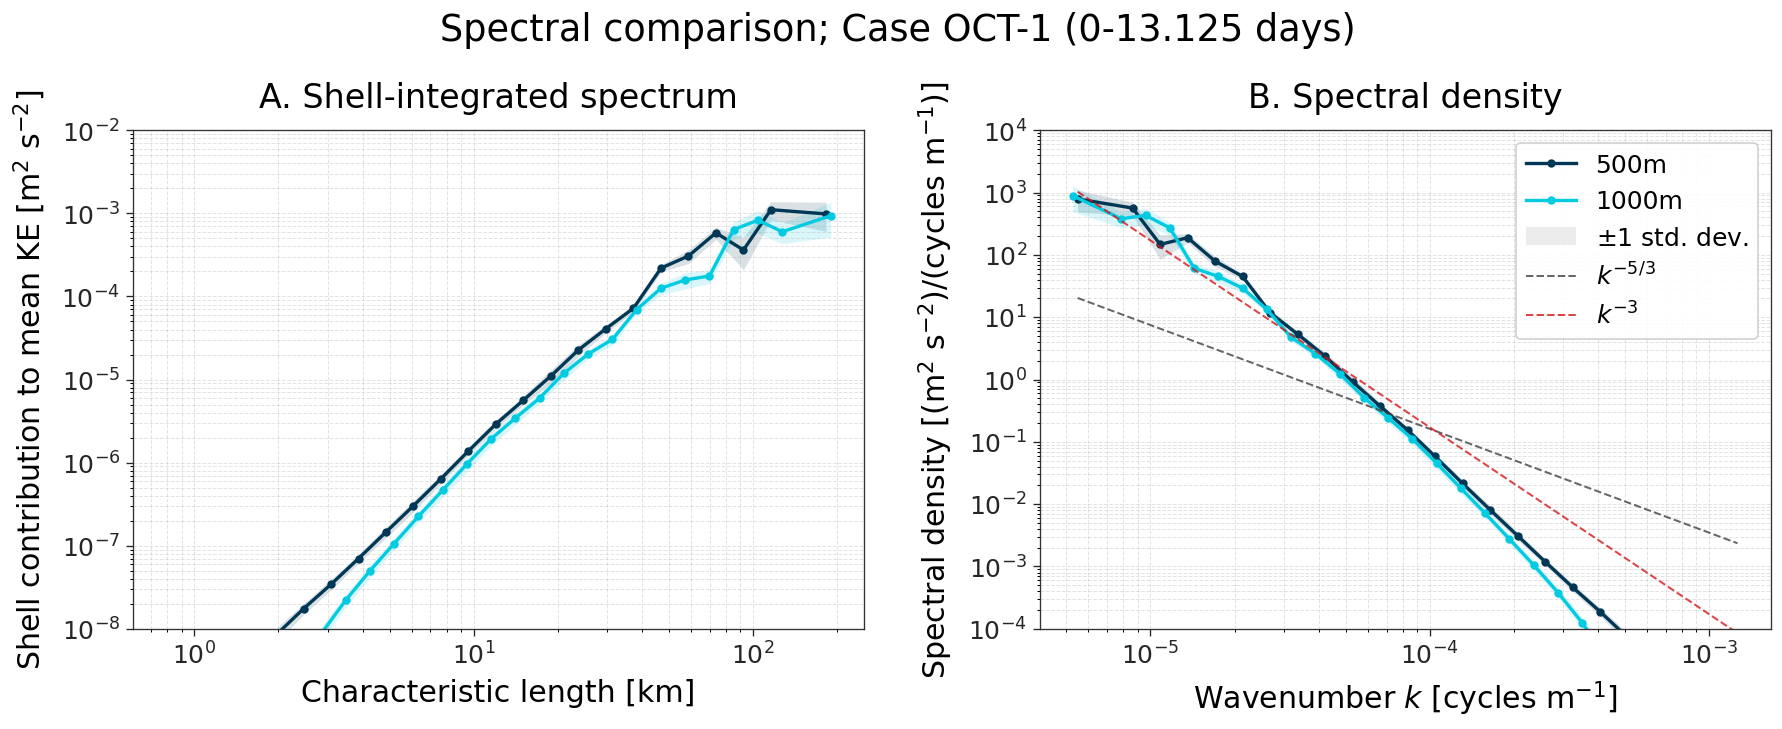

In [23]:
# ============================================================
# 4. TWO-PANEL SPECTRAL COMPARISON
# ============================================================

if not spectra:
    raise ValueError("No datasets were included in CASE_NAMES.")

# Same plotting theme/helpers as calculate_EDS.
oa._apply_consistent_style()

# Explicitly enlarged for the horizontal two-panel layout.
TITLE_SIZE = 22
SUBTITLE_SIZE = 20
LABEL_SIZE = 18
TICK_SIZE = 15
LEGEND_SIZE = 15

fig, (ax_shell, ax_density) = plt.subplots(
    1,
    2,
    figsize=(15.0, 6.2),
    facecolor="white",
)

oa._set_white_background(fig, ax_shell, ax_density)
oa._style_cartesian_axis(ax_shell, grid=True)
oa._style_cartesian_axis(ax_density, grid=True)

line_width = getattr(ptheme, "THICK_LINE_WIDTH", 2.0)
marker_size = getattr(ptheme, "MARKER_SIZE", 4)
band_alpha = getattr(ptheme, "BAND_ALPHA", 0.15)

for display_name, eds in spectra.items():
    length_km = eds["characteristic_length"].values / 1000.0
    shell_mean = eds["shell_integrated_spectrum"].values
    shell_std = eds["shell_integrated_spectrum_std"].values

    k = eds["wavenumber"].values
    density_mean = eds["spectral_density"].values
    density_std = eds["spectral_density_std"].values

    valid_shell = (
        np.isfinite(length_km)
        & np.isfinite(shell_mean)
        & (length_km > 0)
        & (shell_mean > 0)
    )
    valid_density = (
        np.isfinite(k)
        & np.isfinite(density_mean)
        & (k > 0)
        & (density_mean > 0)
    )

    shell_line, = ax_shell.loglog(
        length_km[valid_shell],
        shell_mean[valid_shell],
        "-o",
        lw=line_width,
        ms=marker_size,
        label=display_name,
    )

    density_line, = ax_density.loglog(
        k[valid_density],
        density_mean[valid_density],
        "-o",
        lw=line_width,
        ms=marker_size,
        label=display_name,
    )

    if SHOW_STD_BANDS:
        if np.any(np.isfinite(shell_std[valid_shell])):
            shell_lo = np.maximum(
                shell_mean[valid_shell] - shell_std[valid_shell],
                1e-30,
            )
            shell_hi = shell_mean[valid_shell] + shell_std[valid_shell]

            ax_shell.fill_between(
                length_km[valid_shell],
                shell_lo,
                shell_hi,
                color=shell_line.get_color(),
                alpha=band_alpha,
                linewidth=0,
            )

        if np.any(np.isfinite(density_std[valid_density])):
            density_lo = np.maximum(
                density_mean[valid_density] - density_std[valid_density],
                1e-30,
            )
            density_hi = density_mean[valid_density] + density_std[valid_density]

            ax_density.fill_between(
                k[valid_density],
                density_lo,
                density_hi,
                color=density_line.get_color(),
                alpha=band_alpha,
                linewidth=0,
            )

# Same reference-slope calculation and styling as calculate_EDS.
if SHOW_REFERENCE_SLOPES:
    first_eds = next(iter(spectra.values()))
    common_k = first_eds["wavenumber"].values

    stacked_density = np.asarray([
        eds["spectral_density"].values
        for eds in spectra.values()
    ])
    reference_density = np.nanmedian(stacked_density, axis=0)

    valid_ref = (
        np.isfinite(common_k)
        & np.isfinite(reference_density)
        & (common_k > 0)
        & (reference_density > 0)
    )

    k_plot = common_k[valid_ref]
    E_plot = reference_density[valid_ref]

    if len(k_plot) >= 3:
        mid = len(k_plot) // 2
        k0 = k_plot[mid]
        E0 = E_plot[mid]

        k_ref = np.array([k_plot[0], k_plot[-1]])
        y_53 = E0 * (k_ref / k0) ** (-5 / 3)
        y_3 = E0 * (k_ref / k0) ** (-3)

        ax_density.loglog(
            k_ref,
            y_53,
            "--",
            color=oa._color("reference", "0.25"),
            lw=getattr(ptheme, "LINE_WIDTH", 1.2),
            alpha=getattr(ptheme, "REFERENCE_ALPHA", 0.8),
            label=r"$k^{-5/3}$",
        )
        ax_density.loglog(
            k_ref,
            y_3,
            "--",
            color=oa._color("highlight", "#D61418"),
            lw=getattr(ptheme, "LINE_WIDTH", 1.2),
            alpha=getattr(ptheme, "REFERENCE_ALPHA", 0.8),
            label=r"$k^{-3}$",
        )

ax_shell.set_xlabel(
    "Characteristic length [km]",
    fontsize=LABEL_SIZE,
    labelpad=6,
)
ax_shell.set_ylabel(
    r"Shell contribution to mean KE [m$^2$ s$^{-2}$]",
    fontsize=LABEL_SIZE,
    labelpad=8,
)
ax_shell.set_title(
    "A. Shell-integrated spectrum",
    fontsize=SUBTITLE_SIZE,
    pad=14,
)

ax_density.set_xlabel(
    r"Wavenumber $k$ [cycles m$^{-1}$]",
    fontsize=LABEL_SIZE,
    labelpad=6,
)
ax_density.set_ylabel(
    r"Spectral density [(m$^2$ s$^{-2}$)/(cycles m$^{-1}$)]",
    fontsize=LABEL_SIZE,
    labelpad=8,
)
ax_density.set_title(
    "B. Spectral density",
    fontsize=SUBTITLE_SIZE,
    pad=14,
)

for ax in (ax_shell, ax_density):
    ax.tick_params(axis="both", which="major", labelsize=TICK_SIZE)
    ax.tick_params(axis="both", which="minor", labelsize=TICK_SIZE)

if XLIM_LENGTH_KM is not None:
    ax_shell.set_xlim(XLIM_LENGTH_KM)
if XLIM_WAVENUMBER is not None:
    ax_density.set_xlim(XLIM_WAVENUMBER)
if YLIM_SHELL is not None:
    ax_shell.set_ylim(YLIM_SHELL)
if YLIM_DENSITY is not None:
    ax_density.set_ylim(YLIM_DENSITY)

# Flexible legends plus one standard-deviation entry, as in calculate_EDS.
density_handles, density_labels = ax_density.get_legend_handles_labels()

if SHOW_STD_BANDS:
    std_patch = patches.Patch(
        facecolor="0.5",
        edgecolor="none",
        alpha=band_alpha,
        label=r"$\pm 1$ std. dev.",
    )

    density_handles.insert(len(spectra), std_patch)
    density_labels.insert(len(spectra), r"$\pm 1$ std. dev.")

ax_density.legend(
    density_handles,
    density_labels,
    loc="upper right",
    frameon=True,
    fontsize=LEGEND_SIZE,
)

first_attrs = next(iter(spectra.values())).attrs
layer_index = int(first_attrs["layer_index"])
snapshot_index = first_attrs["snapshot_time_index"]
range_start = first_attrs.get("snapshot_range_start")
range_end = first_attrs.get("snapshot_range_end")

if snapshot_index is not None:
    display_day = float(first_attrs["display_day"])
    title_text = (
        f"Spectral comparison; {RUN_TITLE_INFO} (T = {display_day:g} days)"
    )
    time_tag = f"T{display_day:g}d"

elif range_start is not None:
    day_start = float(first_attrs["display_day_start"])
    day_end = float(first_attrs["display_day_end"])
    title_text = (
        f"Spectral comparison; {RUN_TITLE_INFO} "
        f"({day_start:g}-{day_end:g} days)"
    )
    time_tag = f"T{int(range_start)}-{int(range_end)}"

else:
    title_text = f"Spectral comparison; {RUN_TITLE_INFO} (All timesteps)"
    time_tag = "all_timesteps"

wrapped_title = "\n".join(textwrap.wrap(title_text, width=80))

fig.suptitle(
    wrapped_title,
    fontsize=TITLE_SIZE,
    y=0.98,
)

fig.align_ylabels([ax_shell, ax_density])
fig.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.15,
    top=0.82,
    wspace=0.24,
)

first_case_name = Path(next(iter(CASE_NAMES.values()))).stem
figure_path = RESULTS_DIR / (
    f"spectra_comparison_{time_tag}_{first_case_name}.png"
)

if SAVE:
    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )
    print(f"Saved figure to: {figure_path}")

plt.show()
